# Detecção e Segmentação de Fauna Silvestre em Rodovias
Notebook executável do pipeline completo: coleta → pseudo-anotação → EDA → detecção (YOLO26n) →
segmentação (YOLO26n-seg) → avaliação no teste → inferência em vídeo com rastreamento (ByteTrack).

**Como rodar**
- **Google Colab:** Runtime → Change runtime type → GPU. A primeira célula clona o repositório.
  Num ambiente novo não há dados nem pesos: ponha `COLETAR_DADOS = True` e `TREINAR = True`
  e envie os vídeos de teste para `data/` (links em `data/DATASET_SOURCES.md`).
- **Local:** abra com o kernel do `.venv` (ver README). A célula de setup vai para a raiz do repositório.

**Sobre as saídas visíveis:** este notebook foi executado num MacBook Pro M3 Pro (MPS) em 14/09/2026
com `COLETAR_DADOS = False` e `TREINAR = False`. Nesse modo, as células de coleta e treino **exibem os
logs e as curvas reais** das execuções feitas em 13–14/09/2026 (pasta `outputs/`), sem refazer horas de
treino; as células de **avaliação e vídeo rodam de novo** com os pesos treinados.

In [1]:
import os
import re
import subprocess
import sys
from pathlib import Path

# No Colab clona o repositório; localmente usa a raiz (pasta acima de notebooks/)
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/SEU_GRUPO/wildlife-roadkill-cv.git"  # troque pela URL real do grupo

if IN_COLAB:
    if not Path("wildlife-roadkill-cv").exists():
        subprocess.run(["git", "clone", REPO_URL], check=True)
    os.chdir("wildlife-roadkill-cv")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif Path.cwd().name == "notebooks":
    os.chdir("..")

# Controles do pipeline — False = exibe os artefatos das execuções já feitas (outputs/)
COLETAR_DADOS = False  # True: baixa fotos do iNaturalist e gera pseudo-labels com YOLOE-26
TREINAR = False        # True: treina detecção e segmentação do zero (horas)

import torch
import ultralytics

DEVICE = "0" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
PY = sys.executable
print("Diretório:", Path.cwd())
print(f"ultralytics {ultralytics.__version__} · torch {torch.__version__} · device {DEVICE}")

ANSI = re.compile(r"\x1b\[[0-9;]*[A-Za-z]")


def limpar(texto):
    """Remove cores ANSI e barras de progresso (\\r) da saída do Ultralytics."""
    linhas = []
    for linha in re.split(r"[\r\n]", ANSI.sub("", texto)):
        if linha.strip() and "━" not in linha and "(frame " not in linha:
            linhas.append(linha)
    return linhas


def mostrar_log(caminho, ultimas=None, filtro=None):
    """Exibe um log real salvo em outputs/logs (usado quando a etapa não é re-executada)."""
    p = Path(caminho)
    if not p.exists():
        print(f"[aviso] {caminho} não encontrado — rode a etapa com a flag correspondente = True")
        return
    linhas = limpar(p.read_text(errors="replace"))
    if filtro:
        linhas = [l for l in linhas if re.search(filtro, l)]
    print(f"--- {caminho}")
    print("\n".join(linhas[-ultimas:] if ultimas else linhas))


def rodar(*args, ultimas=None):
    """Roda um script do pipeline e mostra a saída sem as barras de progresso."""
    r = subprocess.run([PY, *map(str, args)], capture_output=True, text=True)
    linhas = limpar(r.stdout + r.stderr)
    print("\n".join(linhas[-ultimas:] if ultimas else linhas))
    if r.returncode != 0:
        raise RuntimeError(f"falhou (código {r.returncode})")

Diretório: /Users/yasmincosta/Documents/visao
ultralytics 8.4.150 · torch 2.14.0 · device mps


## Fase 1 — Dataset
Fotos reais do **iNaturalist** (research grade, licenças CC, 180 por espécie) e **pseudo-labels**
(caixa + máscara) geradas pelo modelo open-vocabulary **YOLOE-26**; a classe vem do táxon do
iNaturalist. Detalhes e atribuições em `data/DATASET_SOURCES.md` e `data/ATRIBUICAO_imagens.csv`.

In [2]:
if COLETAR_DADOS:
    rodar("scripts/00_download_inaturalist.py", "--out_dir", "data/inaturalist", "--per_class", 180)
    Path("models").mkdir(exist_ok=True)
    if not Path("models/yoloe-26l-seg.pt").exists():
        import urllib.request
        urllib.request.urlretrieve(
            "https://github.com/ultralytics/assets/releases/download/v8.4.0/yoloe-26l-seg.pt",
            "models/yoloe-26l-seg.pt")
    rodar("scripts/00b_autolabel_yoloe.py", "--model", "models/yoloe-26l-seg.pt", "--overwrite")
else:
    mostrar_log("outputs/logs/00b_autolabel.log", filtro=r"^\[|Relatório")

--- outputs/logs/00b_autolabel.log
[capivara] 159/180 imagens rotuladas, 218 instâncias, 21 descartadas
[cachorro_do_mato] 127/180 imagens rotuladas, 140 instâncias, 53 descartadas
[tamandua_bandeira] 147/180 imagens rotuladas, 174 instâncias, 33 descartadas
[tatu] 162/180 imagens rotuladas, 182 instâncias, 18 descartadas
[lobo_guara] 118/180 imagens rotuladas, 121 instâncias, 62 descartadas
Relatório em outputs/autolabel/report.json; mosaicos de revisão em outputs/autolabel


In [3]:
# Splits fixos 70/15/15 com seed 42 (detecção e segmentação)
if COLETAR_DADOS:
    rodar("scripts/01_prepare_dataset.py", "--raw_dir", "data/raw", "--out_dir", "data/processed", "--seed", 42)
    rodar("scripts/01_prepare_dataset.py", "--raw_dir", "data/raw_seg", "--out_dir", "data/processed",
          "--seed", 42, "--task", "segment")
else:
    mostrar_log("outputs/logs/01_detect.log")

--- outputs/logs/01_detect.log
Encontrados 713 pares imagem/label em data/raw
[EDA] distribuição de classes salva em data/processed/eda/eda_class_distribution.png
[EDA] total de imagens: 713
[EDA] instâncias por classe: {'capivara': 218, 'cachorro_do_mato': 140, 'tamandua_bandeira': 174, 'tatu': 182, 'lobo_guara': 121}
[EDA] imagens por classe: {'capivara': 159, 'cachorro_do_mato': 127, 'tamandua_bandeira': 147, 'tatu': 162, 'lobo_guara': 118}
[EDA] resolução média: 923x766
[split] train: 499 imagens
[split] val: 106 imagens
[split] test: 108 imagens
Concluído. Dataset em data/processed/detect (ver config/classes.yaml).


### EDA — distribuição de classes e instâncias por split
Evidência de desbalanceamento (capivara × lobo-guará). Os splits abaixo contam os arquivos de label;
15 imagens (GIF salvo como `.jpg`) são descartadas pelo Ultralytics — ver `data/DATASET_SOURCES.md`.

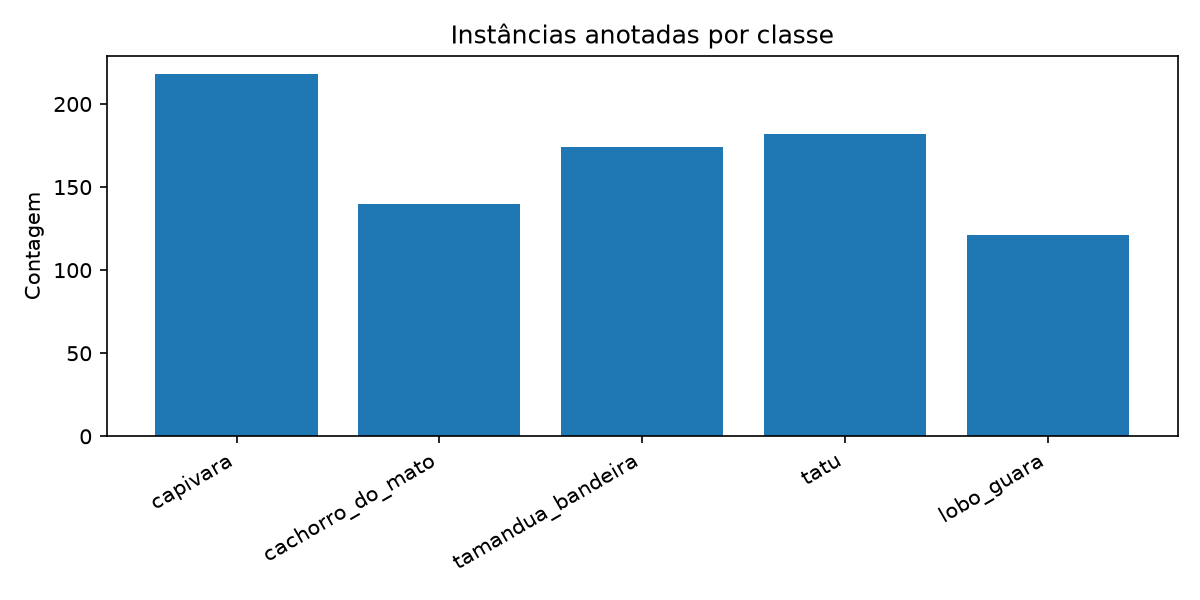

{
  "total_imagens": 713,
  "instancias_por_classe": {
    "capivara": 218,
    "cachorro_do_mato": 140,
    "tamandua_bandeira": 174,
    "tatu": 182,
    "lobo_guara": 121
  },
  "imagens_por_classe": {
    "capivara": 159,
    "cachorro_do_mato": 127,
    "tamandua_bandeira": 147,
    "tatu": 162,
    "lobo_guara": 118
  },
  "resolucao_media": [
    923,
    766
  ],
  "seed": 42,
  "splits": {
    "train": 499,
    "val": 106,
    "test": 108
  }
}


,train,val,test,total
capivara,159,36,23,218
cachorro_do_mato,95,25,20,140
tamandua_bandeira,119,23,32,174
tatu,135,26,21,182
lobo_guara,82,14,25,121


In [4]:
import json
from collections import Counter

from IPython.display import Image, display
import pandas as pd

display(Image(filename="data/processed/eda/eda_class_distribution.png", width=700))
print(json.dumps(json.load(open("data/processed/eda/eda_summary_detect.json")), indent=2, ensure_ascii=False))

nomes = ["capivara", "cachorro_do_mato", "tamandua_bandeira", "tatu", "lobo_guara"]
tabela = {}
for split in ["train", "val", "test"]:
    cont = Counter()
    for f in Path(f"data/processed/detect/labels/{split}").glob("*.txt"):
        for linha in f.read_text().splitlines():
            if linha.strip():
                cont[nomes[int(linha.split()[0])]] += 1
    tabela[split] = cont
pd.DataFrame(tabela).loc[nomes].assign(total=lambda d: d.sum(axis=1))

## Fase 2 — Baseline de detecção (fine-tuning YOLO26n)
Hiperparâmetros: `imgsz=640`, `batch=16`, `epochs=100`, `patience=20`, `seed=42`, otimizador automático
(AdamW), augmentation padrão do Ultralytics (mosaic, fliplr=0.5, HSV, randaugment, erasing=0.4).

--- outputs/logs/02_train_detect.log
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 114 weight(decay=0.0), 126 weight(decay=0.0005), 126 bias(decay=0.0)
100 epochs completed in 13.573 hours.
--- outputs/logs/02_train_detect.log
YOLO26n summary (fused): 120 layers, 2,375,811 parameters, 0 gradients, 5.3 GFLOPs
                   all        105        123      0.926      0.774      0.902      0.801
              capivara         26         36      0.861      0.694      0.867      0.741
      cachorro_do_mato         25         25          1      0.831       0.95      0.873
     tamandua_bandeira         17         22      0.969      0.727      0.832      0.746
                  tatu         23         26      0.956      0.829      0.943      0.776
            lobo_guara         14         14      0.847       0.79      0.91

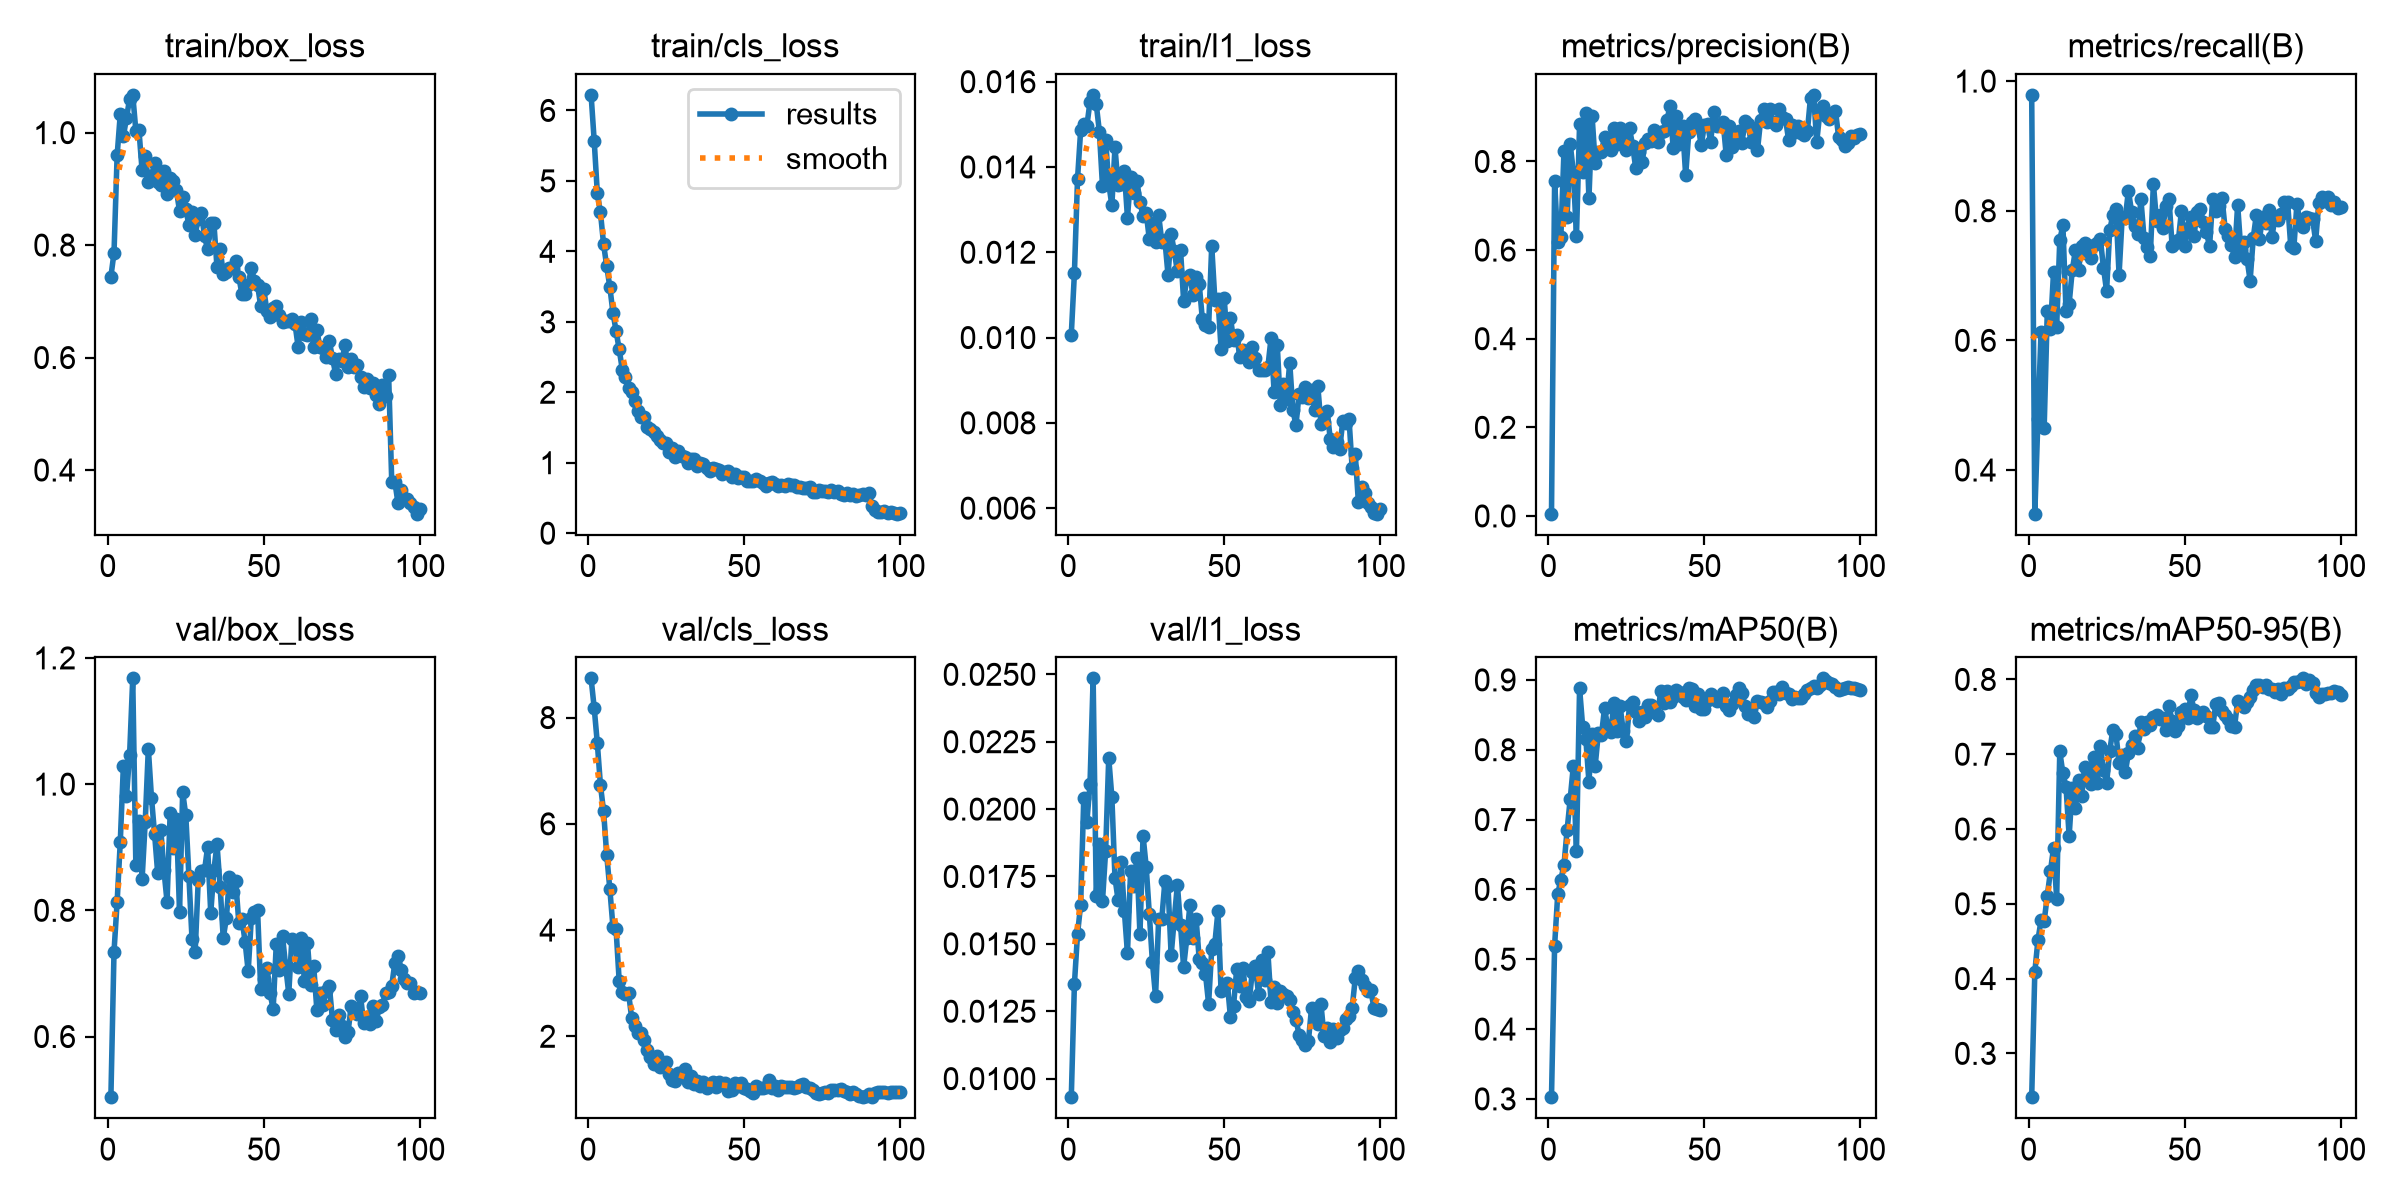

In [5]:
if TREINAR:
    rodar("scripts/02_train_detect.py", "--data", "config/classes.yaml", "--epochs", 100, "--imgsz", 640,
          "--batch", 16, "--device", DEVICE, ultimas=20)
else:
    mostrar_log("outputs/logs/02_train_detect.log", filtro=r"optimizer:|epochs completed")
    mostrar_log("outputs/logs/02_train_detect.log", ultimas=13)
display(Image(filename="outputs/detect/results.png", width=1000))

## Fase 3 — Segmentação de instâncias (YOLO26n-seg)
Mesmos hiperparâmetros da detecção, com as máscaras (polygon) das pseudo-labels.
Registro da execução: o treino foi interrompido na época 28 (suspensão do computador) e retomado do
checkpoint `last.pt` com `resume=True`; parou por *early stopping* na época 86 (melhor: época 66).

--- outputs/logs/03_train_seg.log
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 66, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.
59 epochs completed in 0.637 hours.
--- outputs/logs/03_train_seg.log
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 66, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.
59 epochs completed in 0.637 hours.
Optimizer stripped from /Users/yasmincosta/Documents/visao/outputs/segment/weights/last.pt, 6.5MB
Optimizer stripped from /Users/yasmincosta/Documents/visao/outputs/segment/weights/best.pt, 6.5MB
Validating /Users/yasmincosta/Documents/visao/outputs/segment/weights/best.pt...
Ultralytics 8.4.150 🚀 Pytho

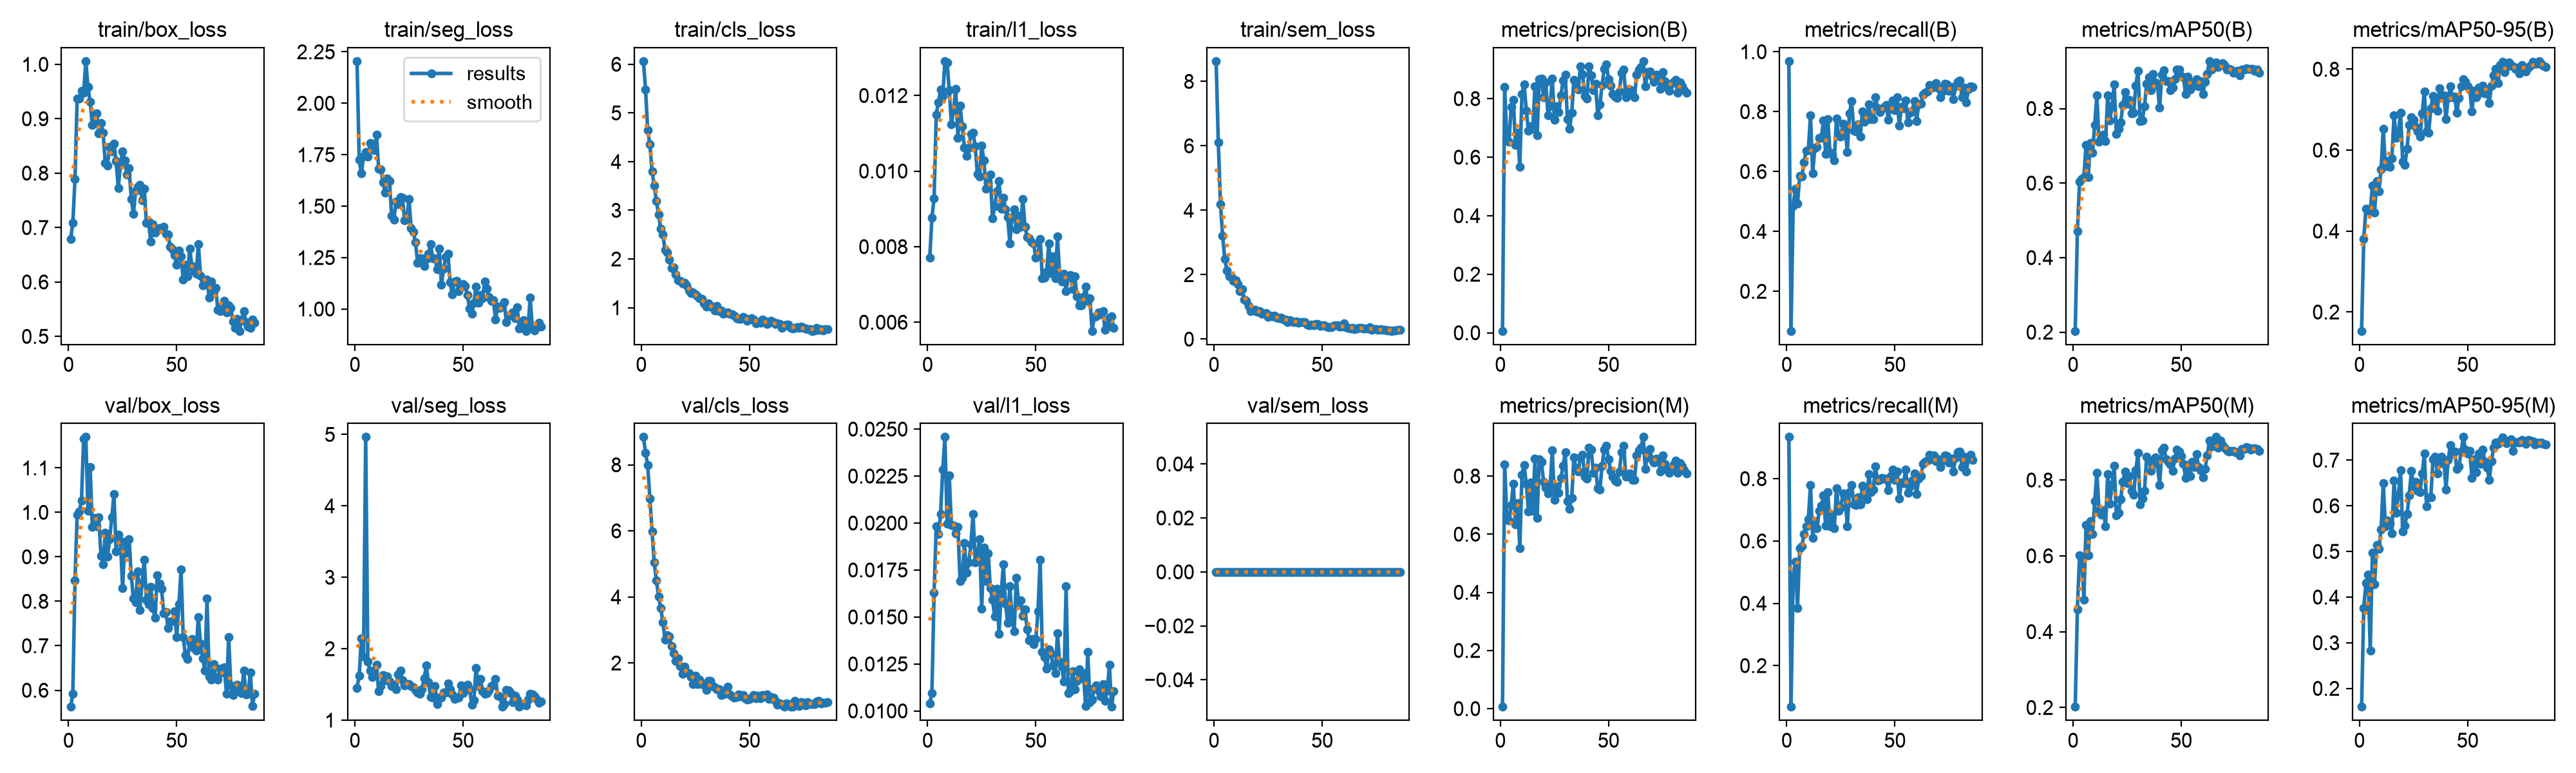

In [6]:
if TREINAR:
    rodar("scripts/03_train_seg.py", "--data", "config/classes_seg.yaml", "--epochs", 100, "--imgsz", 640,
          "--batch", 16, "--device", DEVICE, ultimas=20)
else:
    mostrar_log("outputs/logs/03_train_seg.log", filtro=r"EarlyStopping|epochs completed")
    mostrar_log("outputs/logs/03_train_seg.log", ultimas=16)
display(Image(filename="outputs/segment/results.png", width=1000))

## Fase 4 — Avaliação no conjunto de teste (nunca visto no treino)
mAP@0.5, mAP@0.5:0.95, precisão, recall, matriz de confusão, IoU médio por classe (acertos) e
exemplos de falsos positivos/negativos. Estas células **rodam de novo** com os pesos treinados.

Ultralytics 8.4.150 🚀 Python-3.12.13 torch-2.14.0 MPS (Apple M3 Pro)
YOLO26n summary (fused): 120 layers, 2,375,811 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2816.9±2307.3 MB/s, size: 855.5 KB)
val: /Users/yasmincosta/Documents/visao/data/processed/detect/images/test/inat_342068652.jpg: ignoring corrupt image/label: Invalid image format GIF. Supported formats are:
images: {'dng', 'png', 'heic', 'tif', 'bmp', 'mpo', 'jpg', 'jpeg', 'avif', 'tiff', 'webp', 'heif', 'jp2'}
videos: {'webm', 'wmv', 'mpg', 'avi', 'mp4', 'mpeg', 'ts', 'gif', 'mkv', 'mov', 'm4v', 'asf'}
val: /Users/yasmincosta/Documents/visao/data/processed/detect/images/test/inat_457021209.jpg: ignoring corrupt image/label: Invalid image format GIF. Supported formats are:
images: {'dng', 'png', 'heic', 'tif', 'bmp', 'mpo', 'jpg', 'jpeg', 'avif', 'tiff', 'webp', 'heif', 'jp2'}
videos: {'webm', 'wmv', 'mpg', 'avi', 'mp4', 'mpeg', 'ts', 'gif', 'mkv', 'mov', 'm4v', 'asf'}
val: /Users/yasm

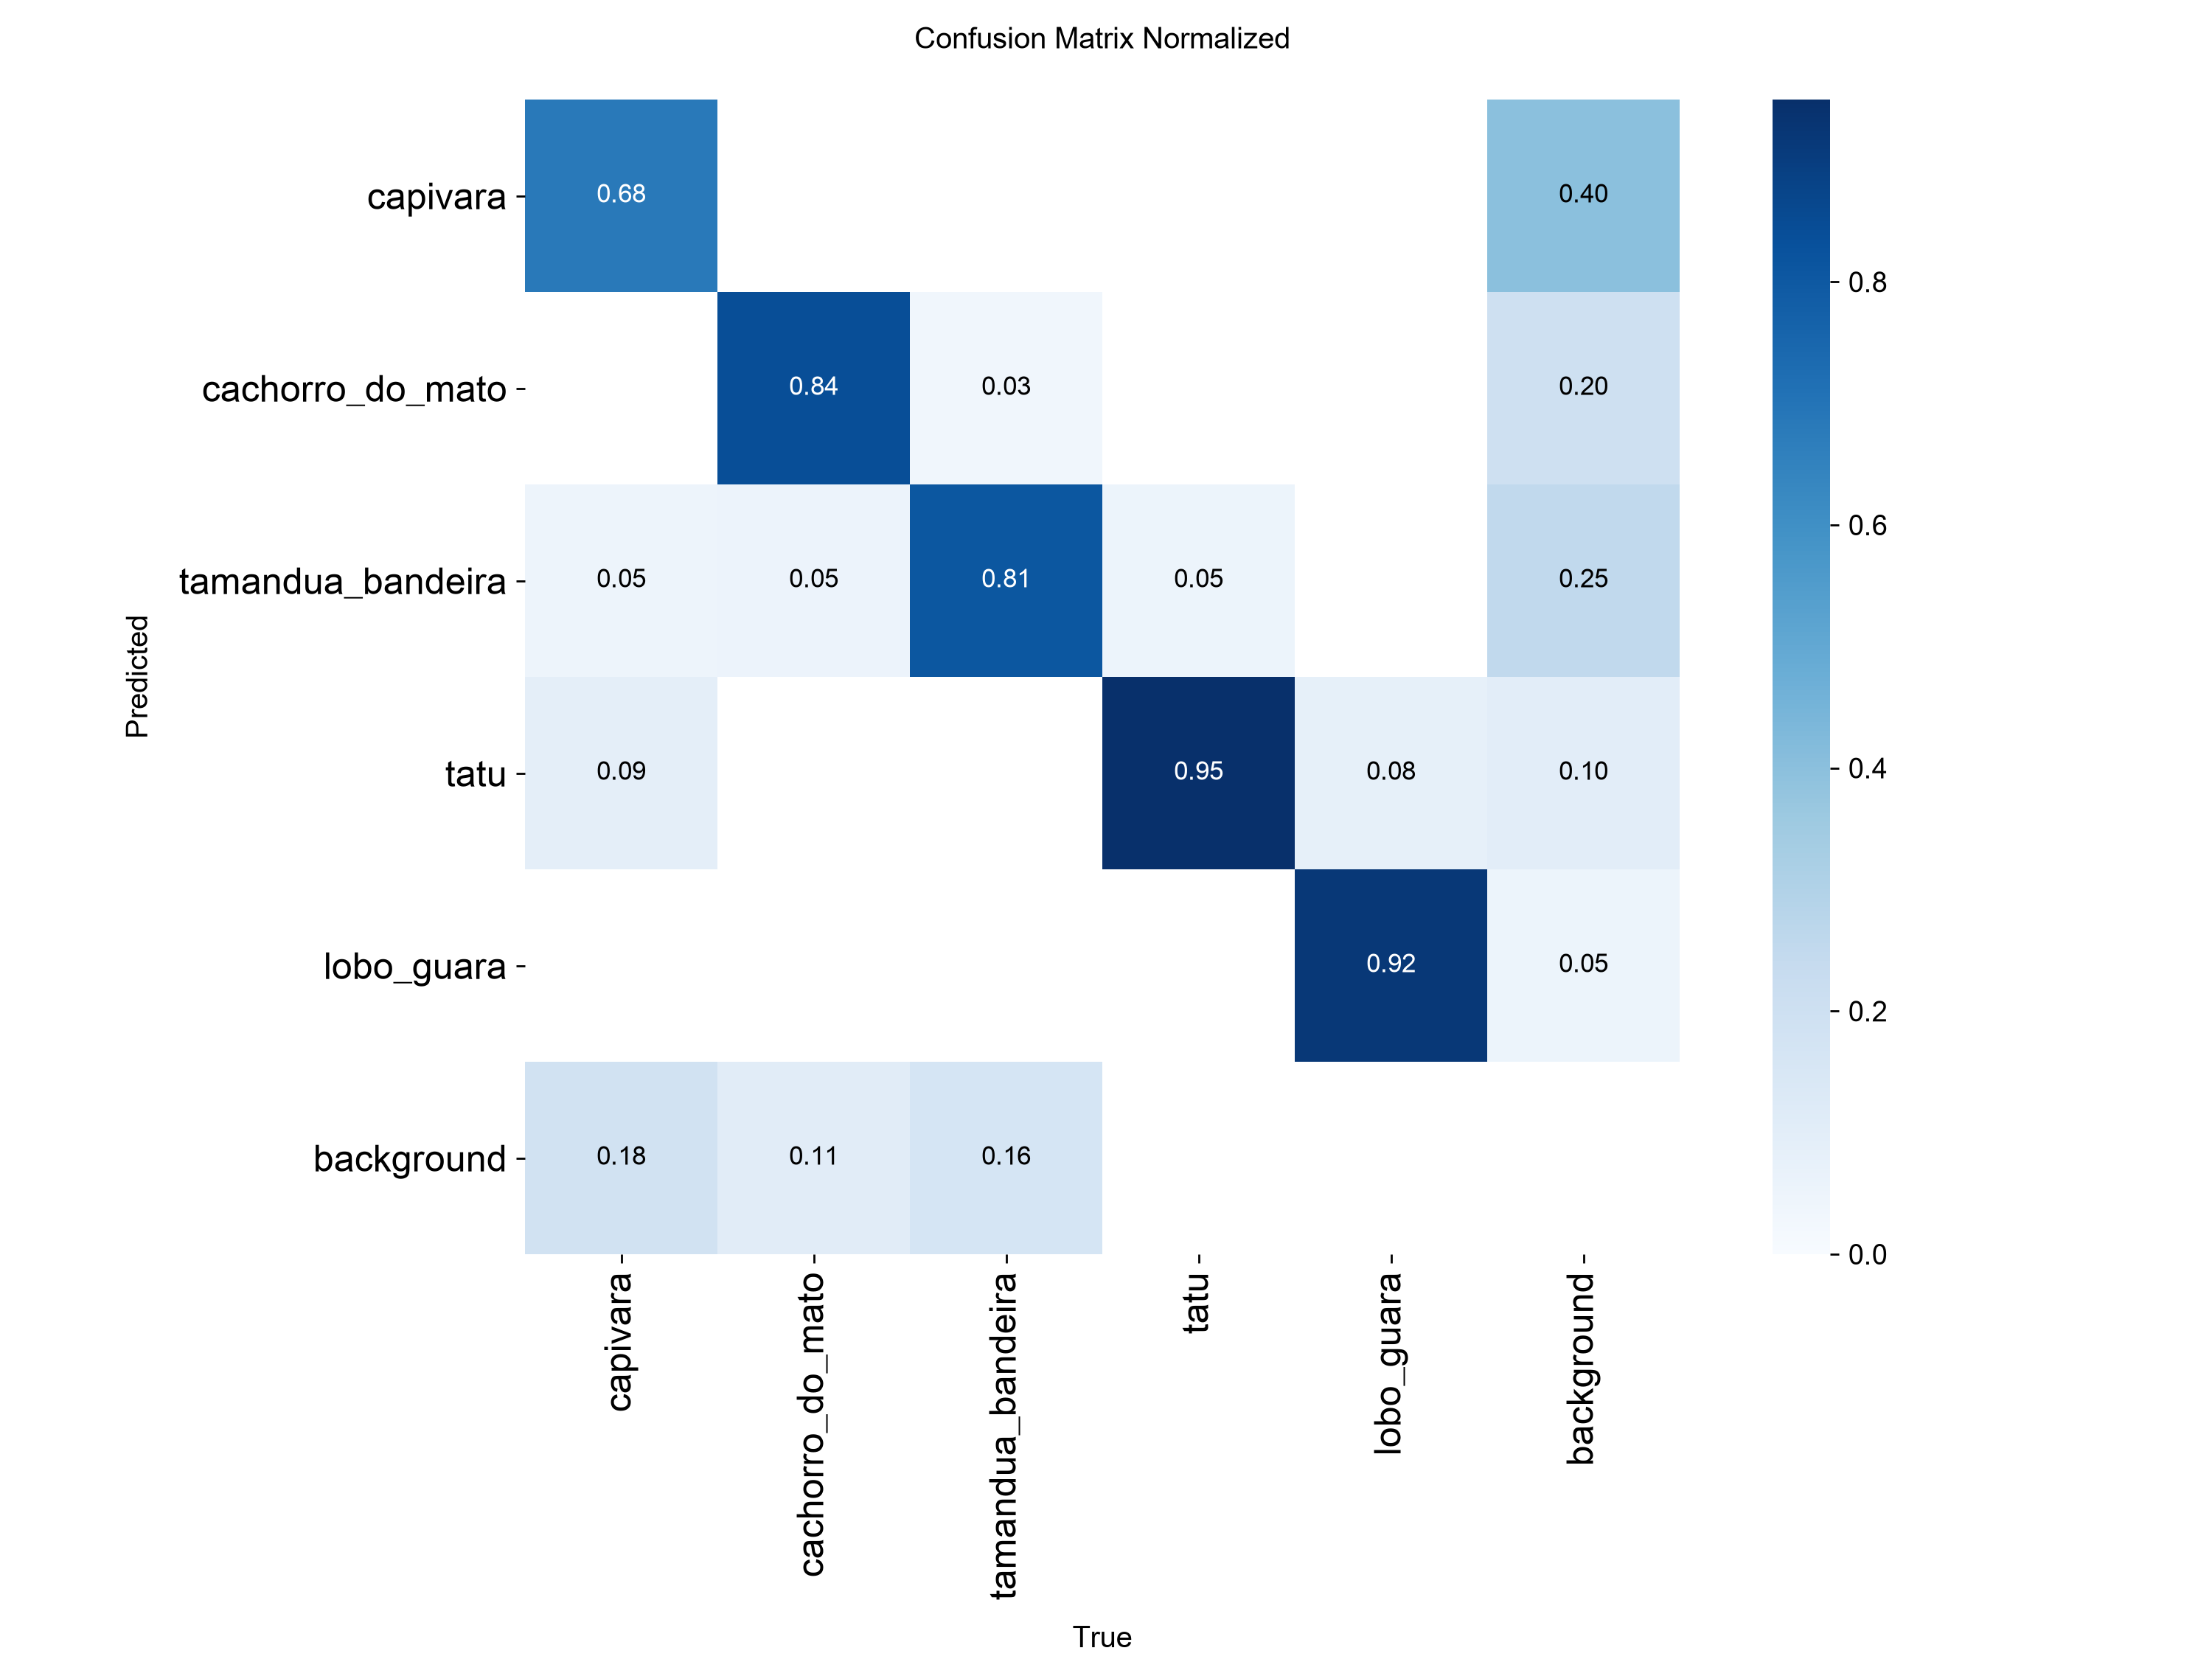

In [7]:
rodar("scripts/04_evaluate.py", "--weights", "outputs/detect/weights/best.pt", "--data", "config/classes.yaml",
      "--split", "test", "--device", DEVICE)
display(Image(filename="outputs/eval/confusion_matrix_normalized.png", width=650))

Ultralytics 8.4.150 🚀 Python-3.12.13 torch-2.14.0 MPS (Apple M3 Pro)
YOLO26n-seg summary (fused): 136 layers, 2,689,859 parameters, 0 gradients, 9.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1097.7±483.5 MB/s, size: 521.7 KB)
val: /Users/yasmincosta/Documents/visao/data/processed/segment/images/test/inat_342068652.jpg: ignoring corrupt image/label: Invalid image format GIF. Supported formats are:
images: {'heic', 'webp', 'tif', 'heif', 'dng', 'jpg', 'mpo', 'tiff', 'jp2', 'avif', 'bmp', 'jpeg', 'png'}
videos: {'wmv', 'avi', 'mpg', 'mpeg', 'asf', 'webm', 'gif', 'mov', 'mkv', 'ts', 'mp4', 'm4v'}
val: /Users/yasmincosta/Documents/visao/data/processed/segment/images/test/inat_457021209.jpg: ignoring corrupt image/label: Invalid image format GIF. Supported formats are:
images: {'heic', 'webp', 'tif', 'heif', 'dng', 'jpg', 'mpo', 'tiff', 'jp2', 'avif', 'bmp', 'jpeg', 'png'}
videos: {'wmv', 'avi', 'mpg', 'mpeg', 'asf', 'webm', 'gif', 'mov', 'mkv', 'ts', 'mp4', 'm4v'}
val: /Users

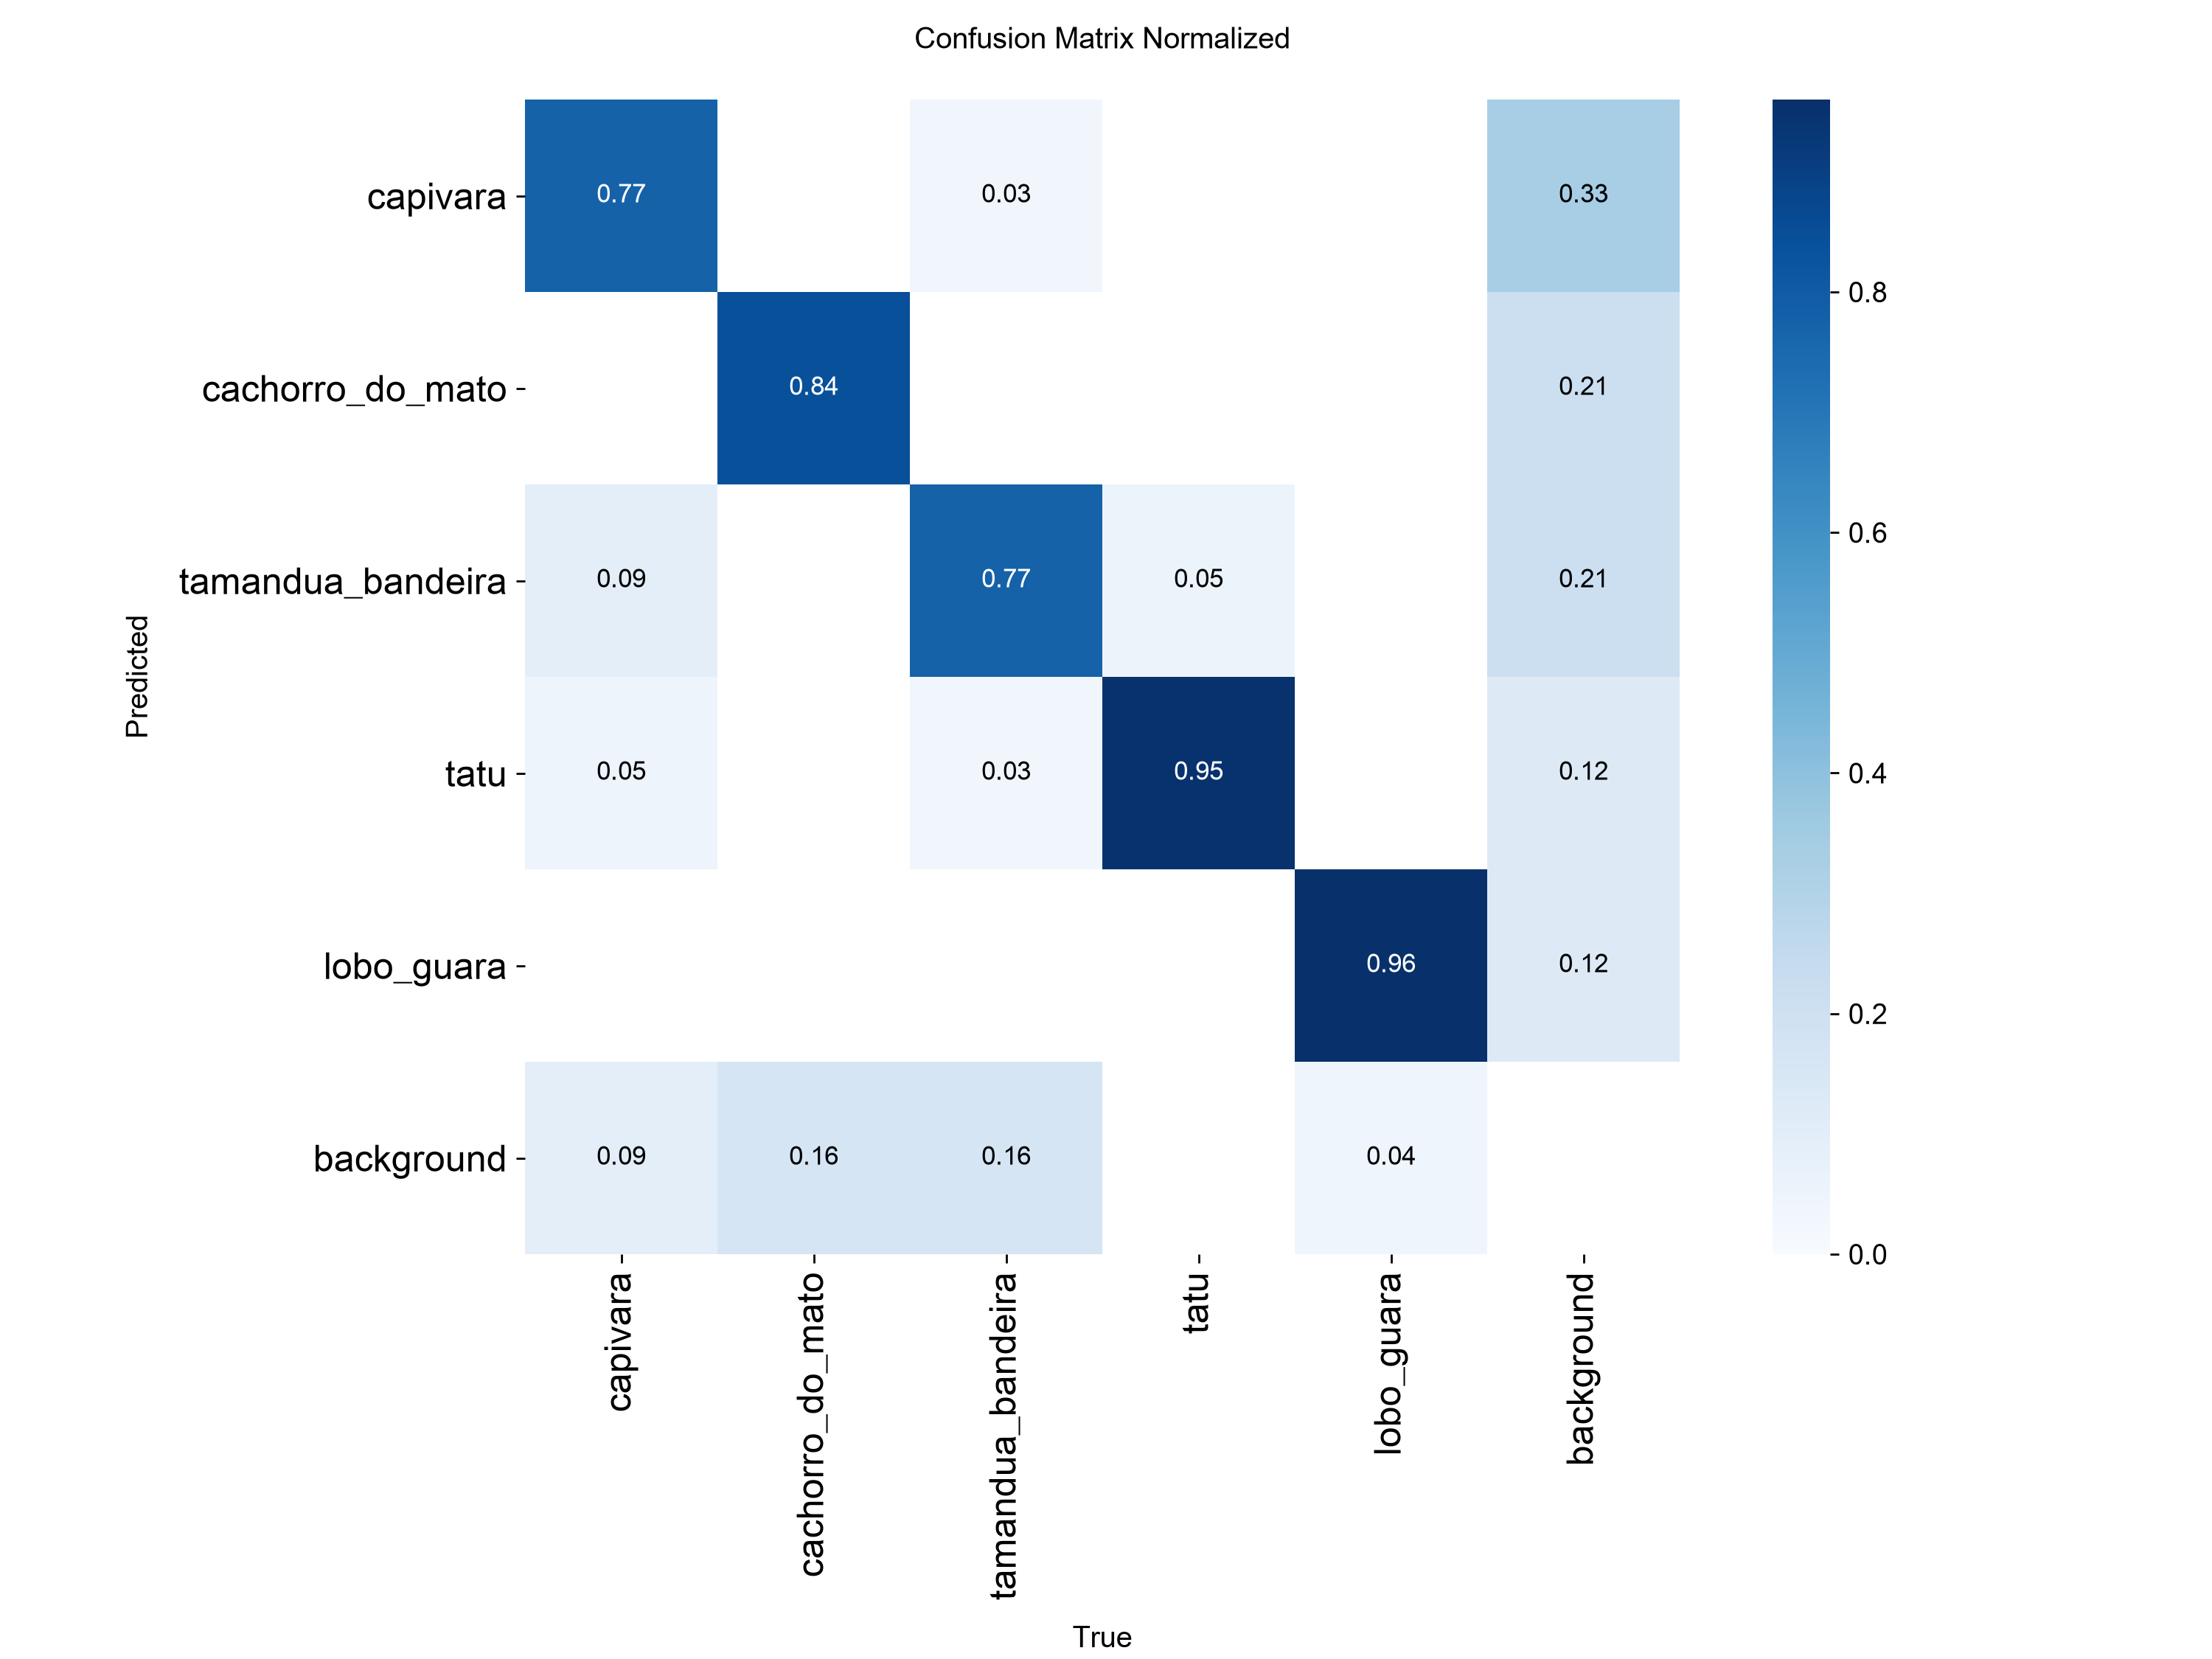

In [8]:
rodar("scripts/04_evaluate.py", "--weights", "outputs/segment/weights/best.pt", "--data", "config/classes_seg.yaml",
      "--split", "test", "--name", "eval_seg", "--compare_boxes_masks", "--device", DEVICE)
display(Image(filename="outputs/eval_seg/confusion_matrix_normalized.png", width=650))

### Caixa × máscara e exemplos de erro
Esquerda: só caixas; direita: só máscaras. Nos exemplos de erro, as caixas do modelo vêm do Ultralytics
e as labels não detectadas aparecem em verde com o prefixo `FN`.

box_vs_mask_inat_326990881.jpg


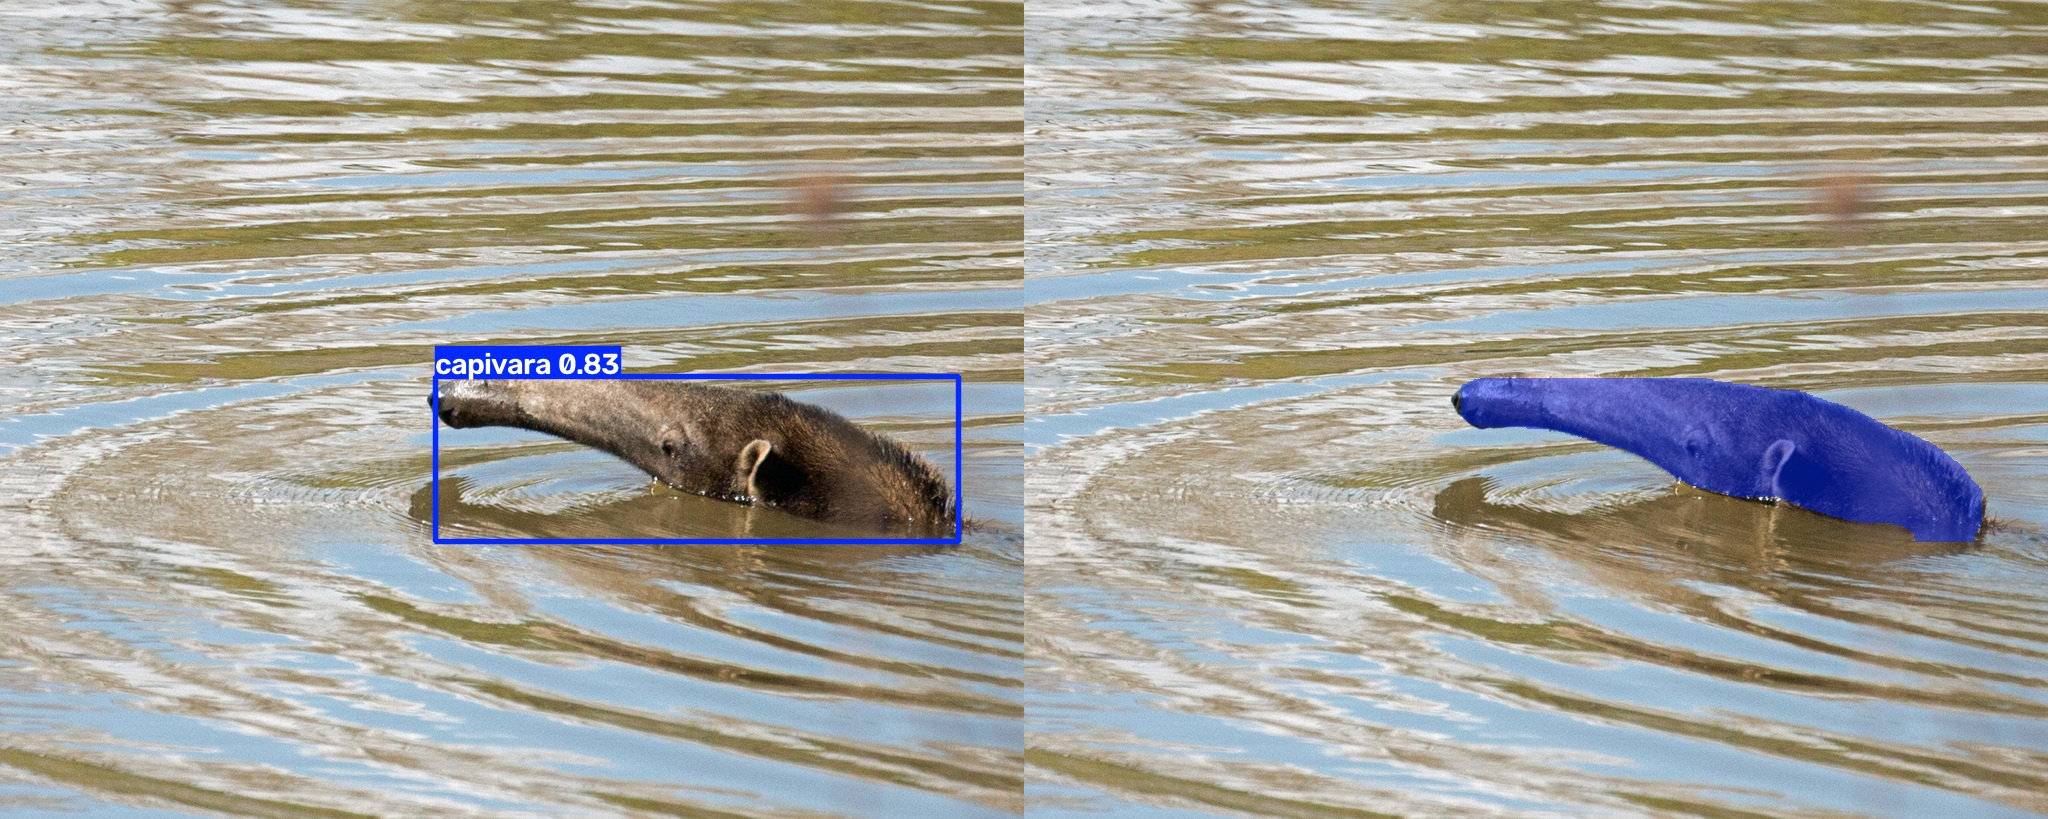

box_vs_mask_inat_342782057.jpg


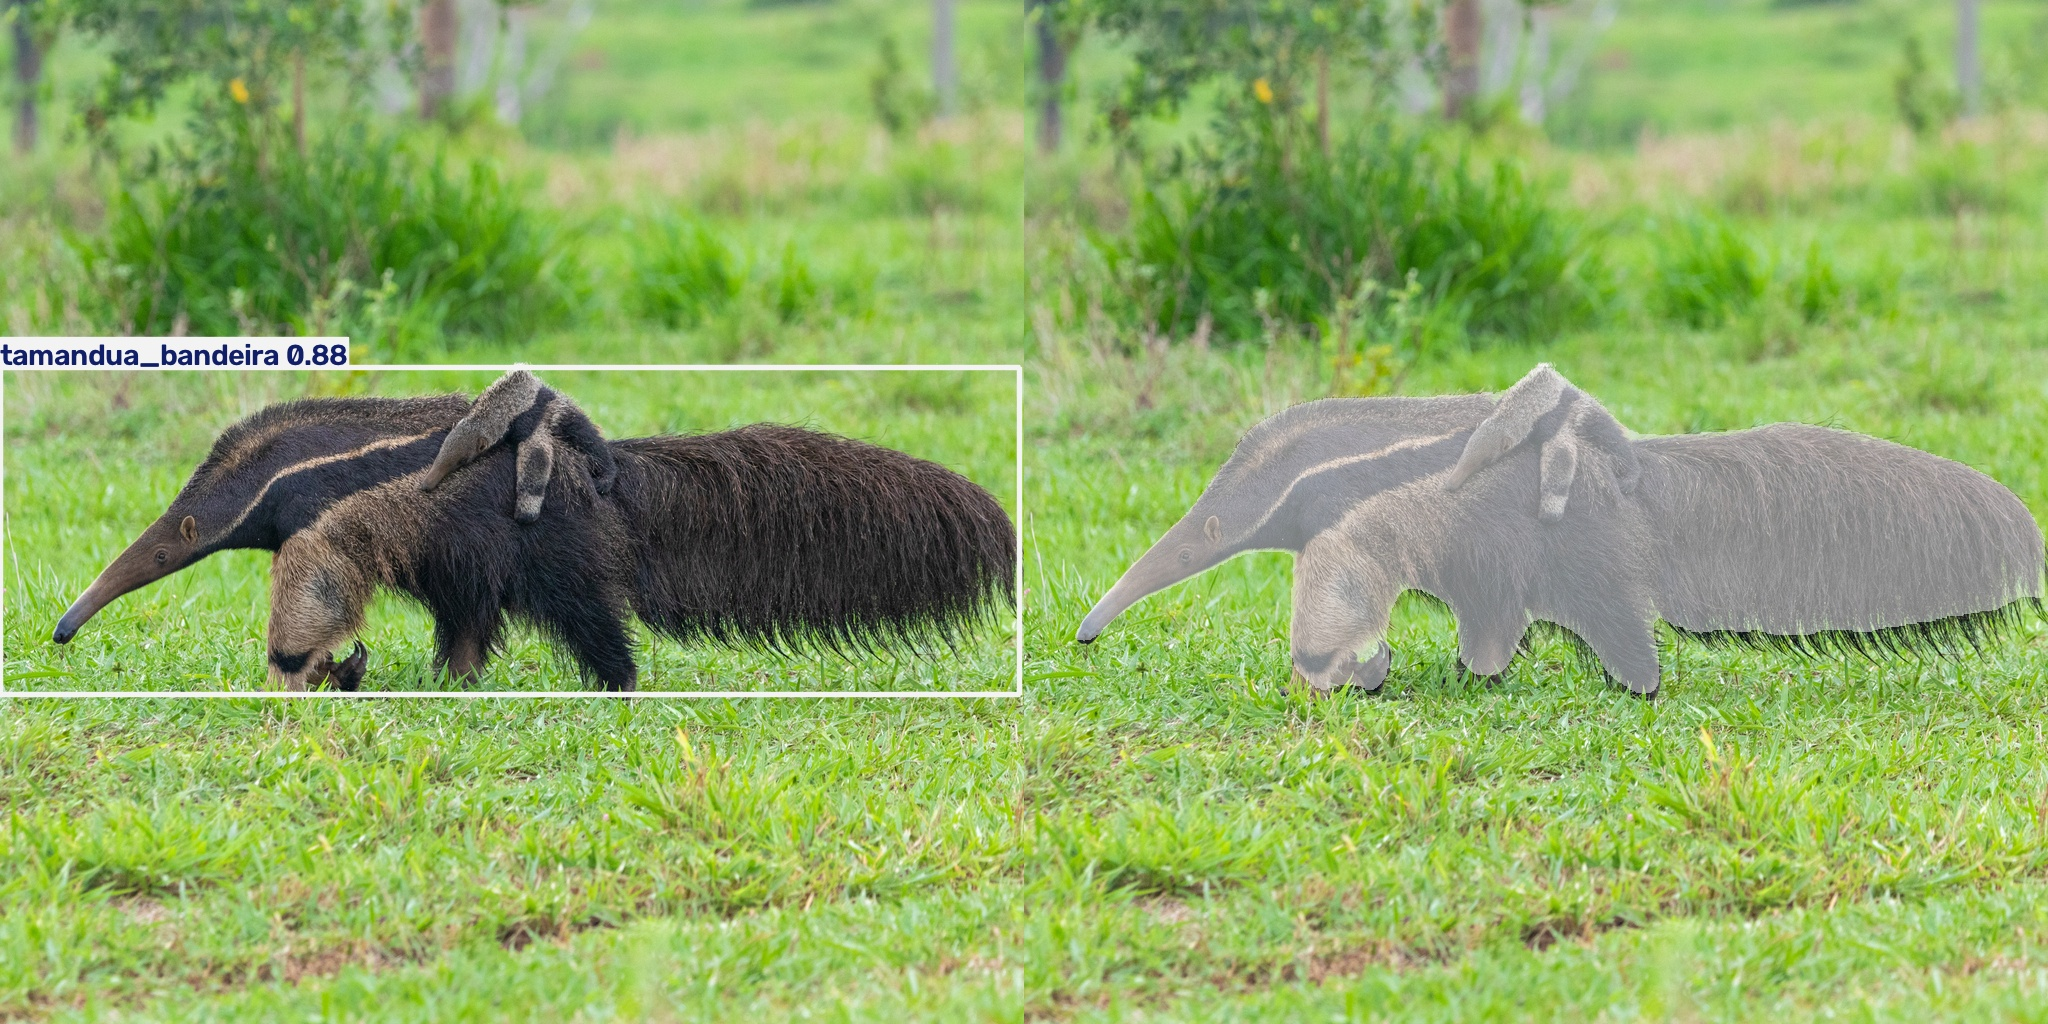

box_vs_mask_inat_343605085.jpg


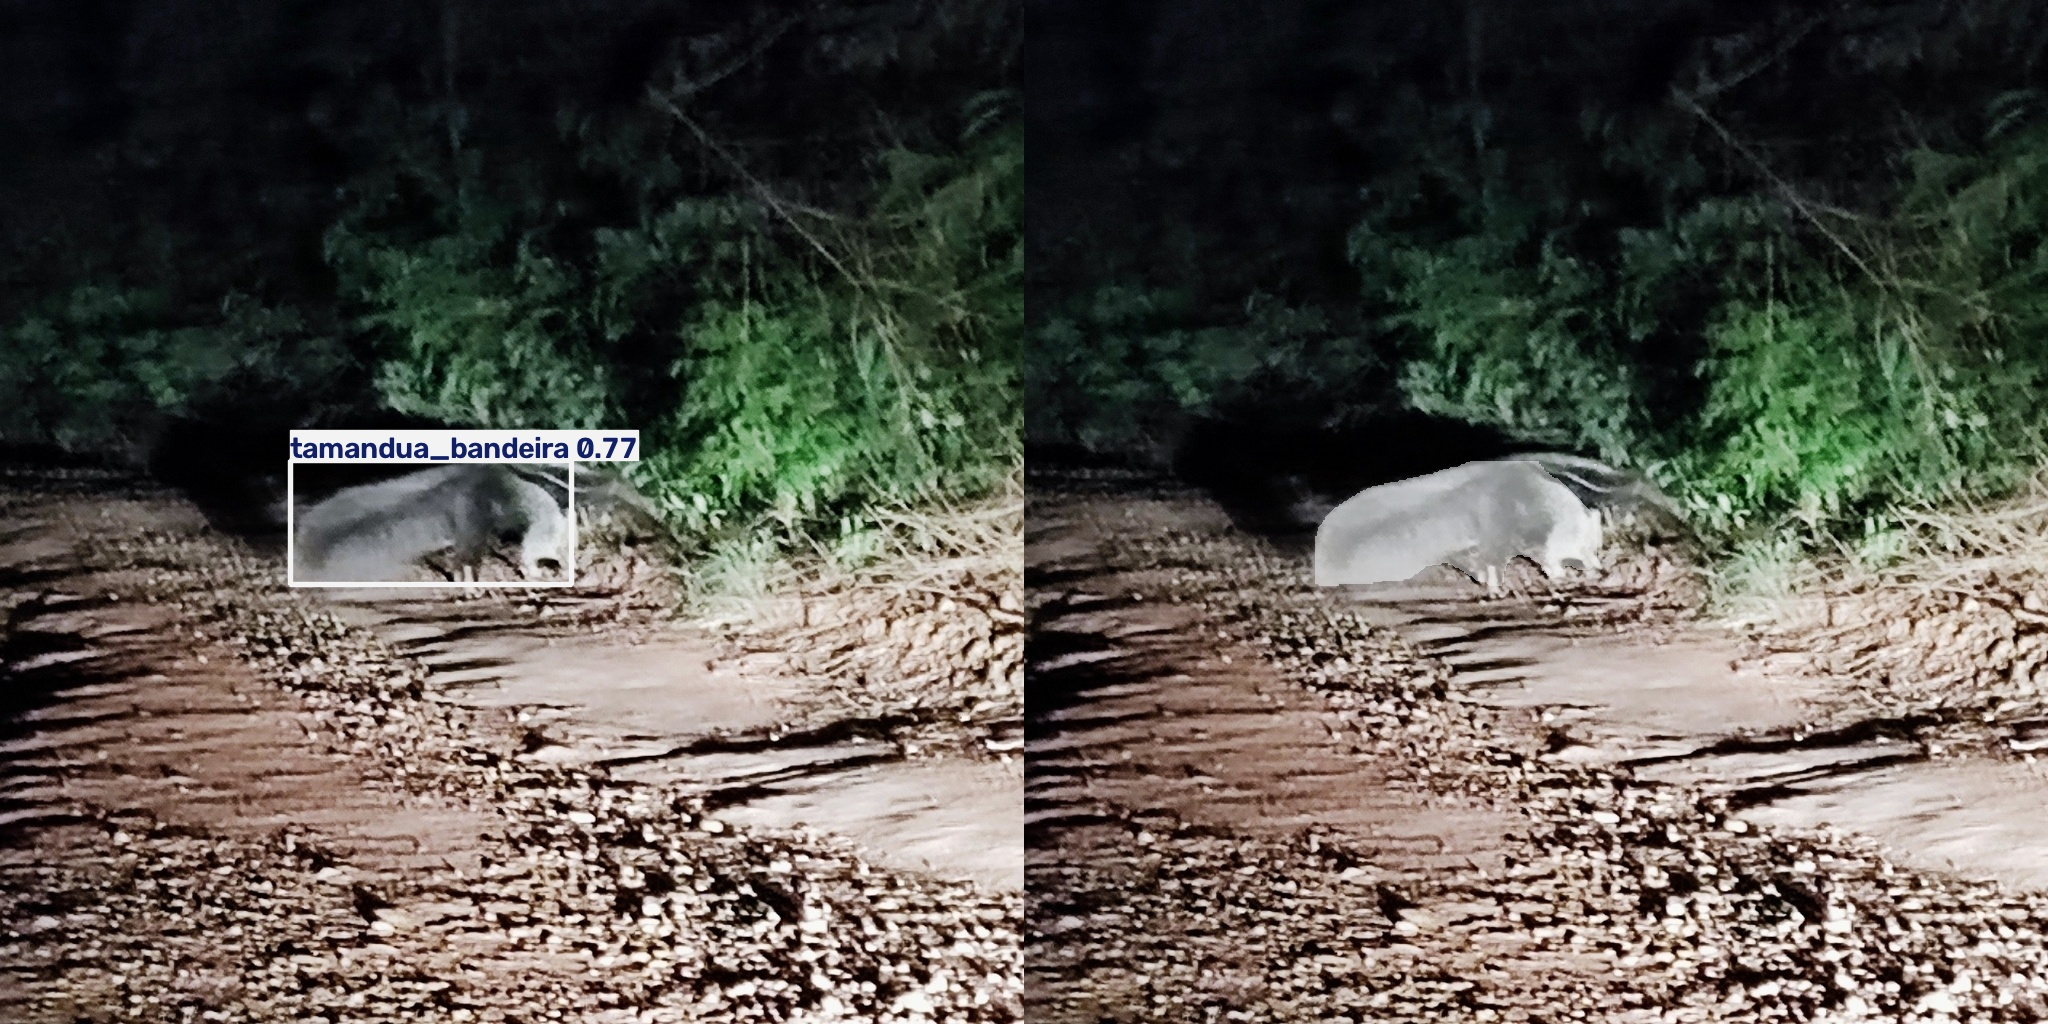

fp_00_inat_703929831_n2.jpg


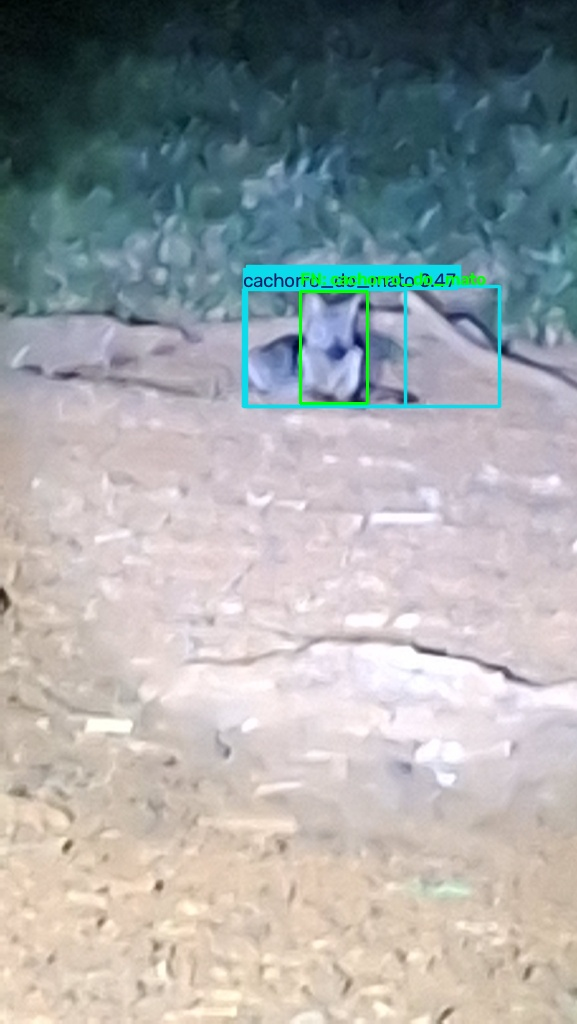

fp_01_inat_731176790_n2.jpg


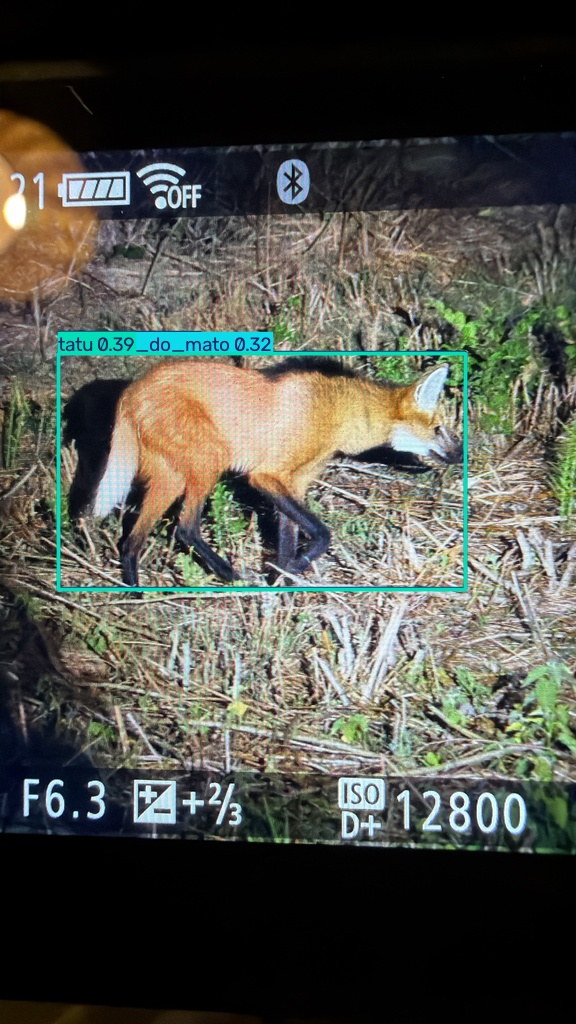

fn_00_inat_457895527_n2.jpg


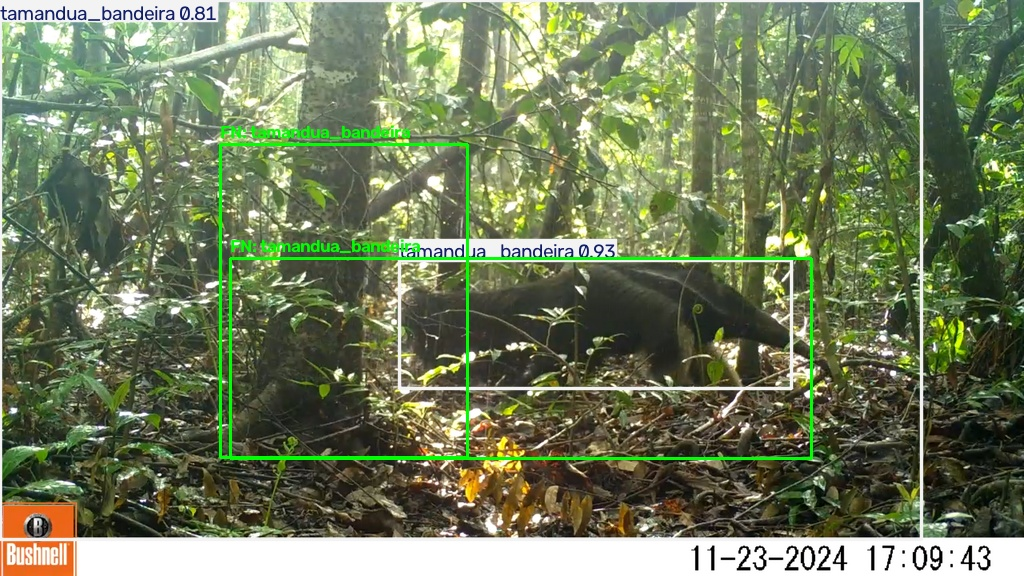

fn_01_inat_725125662_n2.jpg


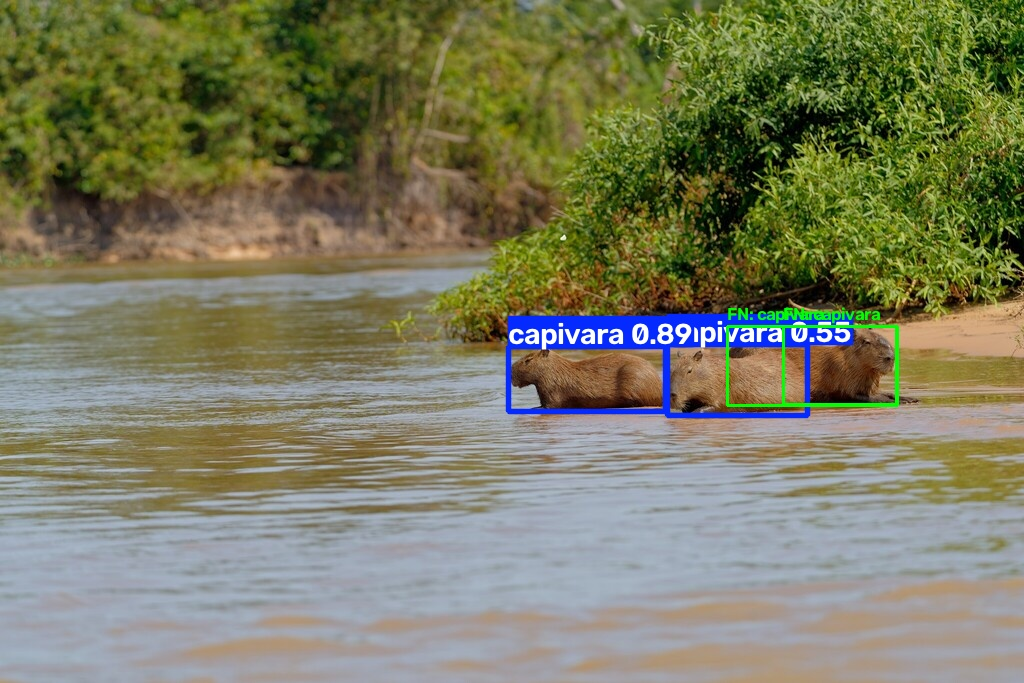

In [9]:
for fig in sorted(Path("outputs/eval_seg/box_vs_mask").glob("*.jpg"))[:3]:
    print(fig.name)
    display(Image(filename=str(fig), width=900))

for tipo in ["fp", "fn"]:
    for fig in sorted(Path("outputs/eval/error_examples").glob(f"{tipo}_*.jpg"))[:2]:
        print(fig.name)
        display(Image(filename=str(fig), width=500))

## Fase 4 — Inferência em vídeo real (≥ 30 s) + rastreamento ByteTrack (bônus)
Vídeos do Wikimedia Commons (autoria e licença em `data/DATASET_SOURCES.md`): capivaras em Miranda-MS
(89 s) e lobo-guará no zoológico de Ueno, Tóquio (84 s). Os vídeos com overlay ficam em `outputs/`;
abaixo, 6 quadros amostrados de cada um.

Inferência COM tracking (ByteTrack) concluída em 2147 frames — critério de bônus atendido.
Vídeo com overlay de detecção/segmentação salvo em: /Users/yasmincosta/Documents/visao/outputs/video_inference
Use este vídeo no Item 4 (vídeo-pitch) e no Item 5 do barema (Aplicação em vídeo).


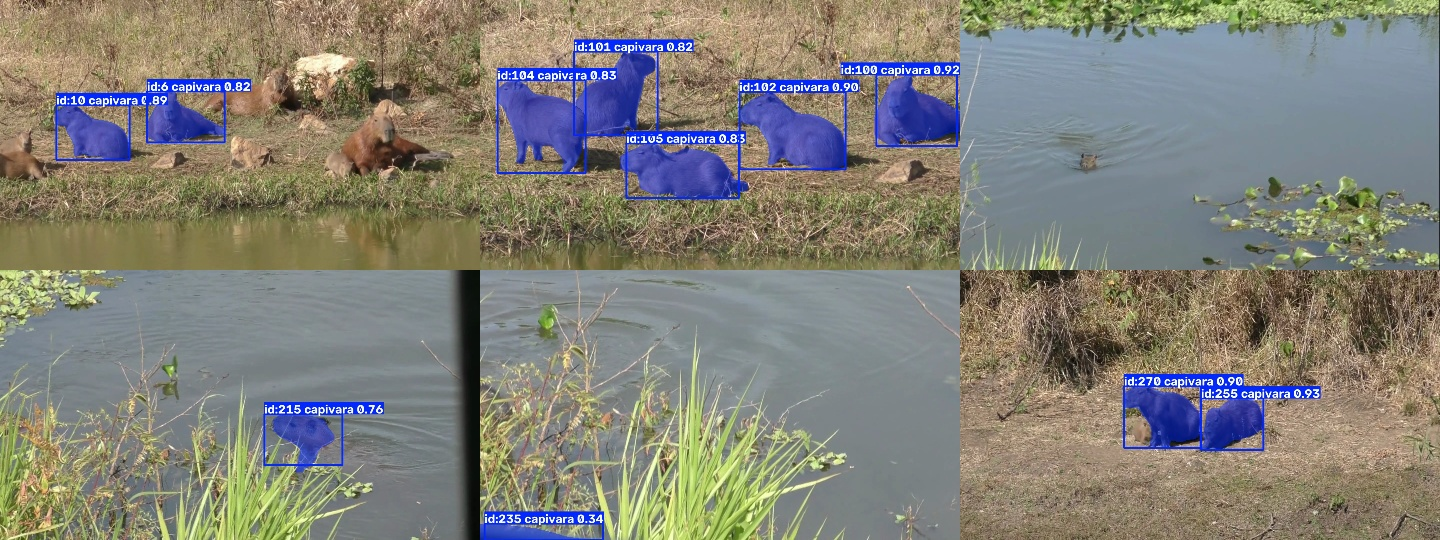

Inferência COM tracking (ByteTrack) concluída em 2523 frames — critério de bônus atendido.
Vídeo com overlay de detecção/segmentação salvo em: /Users/yasmincosta/Documents/visao/outputs/video_lobo_guara
Use este vídeo no Item 4 (vídeo-pitch) e no Item 5 do barema (Aplicação em vídeo).


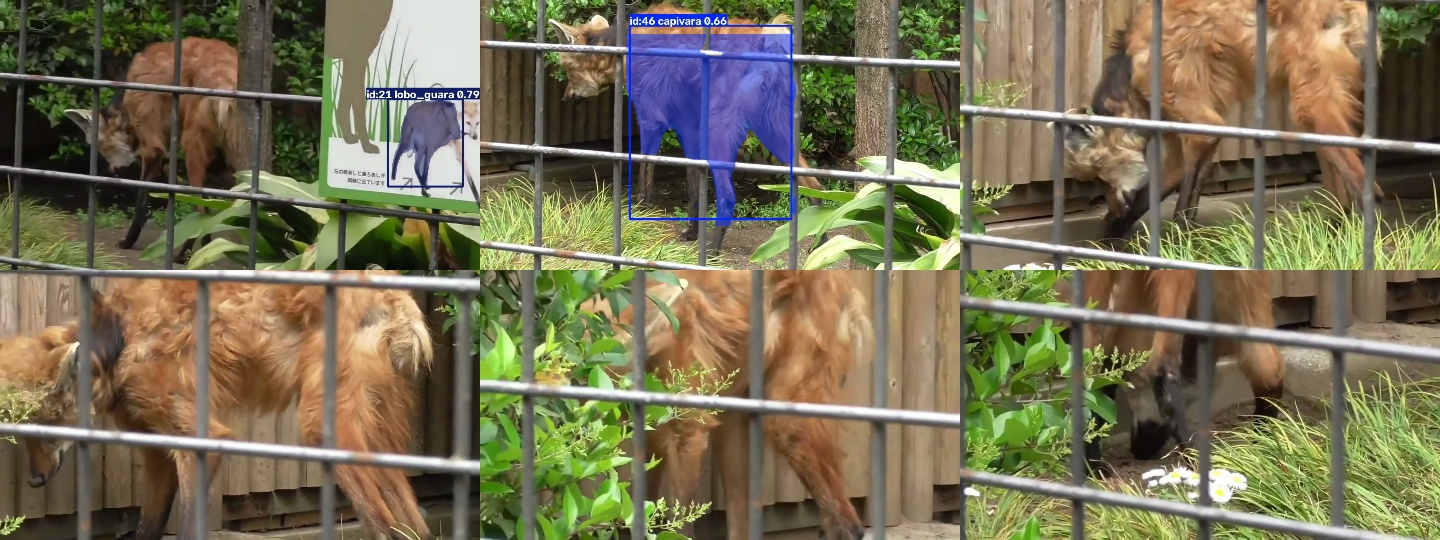

In [10]:
import cv2
import numpy as np

videos = [("data/video_teste.mp4", "video_inference"), ("data/video_lobo_guara.mp4", "video_lobo_guara")]
for fonte, nome in videos:
    if not Path(fonte).exists():
        print(f"[aviso] {fonte} não encontrado — baixe pelos links em data/DATASET_SOURCES.md")
        continue
    rodar("scripts/05_infer_video.py", "--weights", "outputs/segment/weights/best.pt", "--source", fonte,
          "--track", "--name", nome, "--device", DEVICE, ultimas=3)

    # Mosaico com 6 quadros do vídeo gerado
    cap = cv2.VideoCapture(f"outputs/{nome}/{Path(fonte).name}")
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    quadros = []
    for i in np.linspace(n * 0.1, n * 0.9, 6).astype(int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ok, frame = cap.read()
        if ok:
            quadros.append(cv2.resize(frame, (480, 270)))
    cap.release()
    if len(quadros) == 6:
        mosaico = np.vstack([np.hstack(quadros[:3]), np.hstack(quadros[3:])])
        saida = f"outputs/{nome}/amostra_quadros.jpg"
        cv2.imwrite(saida, mosaico)
        display(Image(filename=saida, width=1000))

## Exportar resultados para o Drive (opcional, só no Colab)

In [11]:
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    # !cp -r outputs /content/drive/MyDrive/wildlife-roadkill-cv-outputs